**Digit Recognizer (MNIST)**


Import Library, Seed, & Load Data

In [1]:
# TAHAP 1: PERSIAPAN DATA & IMPORT LIBRARY


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Mengatur Seed agar hasil bisa direproduksi (Syarat Reproducibility Rubrik)
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load Dataset MNIST (Langsung dari Keras, tidak perlu download manual)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Dataset MNIST berhasil dimuat!")
print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset MNIST berhasil dimuat!
Jumlah data latih: 60000
Jumlah data uji: 10000


Eksplorasi Data (EDA)

/tmp/ipykernel_2408/195968021.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
/tmp/ipykernel_2408/195968021.py:21: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


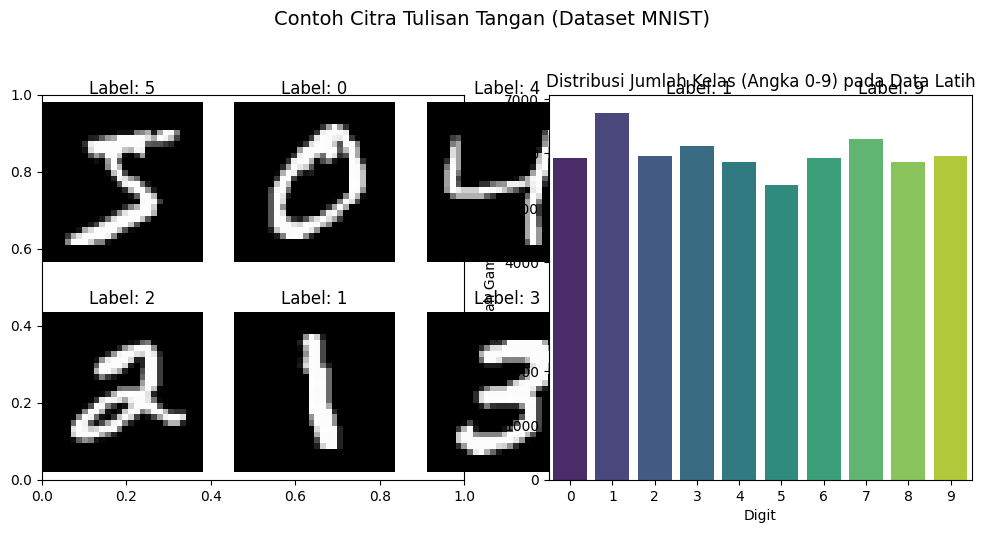

In [2]:
# TAHAP 2: EKSPLORASI DATA (EDA)

plt.figure(figsize=(12, 5))

# Visualisasi 1: Menampilkan 10 Sampel Gambar Pertama dari Data Latih
plt.subplot(1, 2, 1)
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Contoh Citra Tulisan Tangan (Dataset MNIST)', fontsize=14, y=1.05)

# Visualisasi 2: Distribusi Kelas (Jumlah angka 0-9) di Data Latih
plt.subplot(1, 2, 2)
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribusi Jumlah Kelas (Angka 0-9) pada Data Latih')
plt.xlabel('Digit')
plt.ylabel('Jumlah Gambar')

plt.tight_layout()
plt.show()

Preprocessing

In [3]:
# TAHAP 3: PREPROCESSING & RESHAPING


# a. Normalisasi Nilai Piksel dari 0-255 menjadi 0-1
# Hal ini penting untuk menstabilkan dan mempercepat training Neural Network
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# b. Reshape untuk Konvensional (PCA + SVM/RF) -> Matriks 2D diratakan menjadi array 1D (784 pixel)
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)

# c. Reshape untuk Deep Learning (CNN) -> Tambahkan dimensi channel warna (28, 28, 1) (1 = grayscale)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print("Preprocessing selesai!")
print("Shape untuk Konvensional:", X_train_flat.shape)
print("Shape untuk CNN:", X_train_cnn.shape)

Preprocessing selesai!
Shape untuk Konvensional: (60000, 784)
Shape untuk CNN: (60000, 28, 28, 1)


Metode Konvensional (PCA,SVM, dan Random Forest

In [4]:
# TAHAP 4: PELATIHAN MODEL KONVENSIONAL


# Ekstraksi Fitur (Reduksi Dimensi) menggunakan PCA
# Mempertahankan 95% informasi (varians) dari gambar asli untuk menghemat komputasi
print("Mengekstraksi fitur dengan PCA...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)
print(f"Dimensi direduksi dari 784 piksel menjadi {X_train_pca.shape[1]} komponen utama.\n")


# --- Kombinasi 1: PCA + SVM ---
# PERHATIAN: Training SVM pada data 60.000 baris mungkin memakan waktu 1-3 menit
svm_model = SVC(kernel='rbf', random_state=42)

start_train = time.time()
svm_model.fit(X_train_pca, y_train)
svm_train_time = time.time() - start_train

start_infer = time.time()
svm_pred = svm_model.predict(X_test_pca)
svm_infer_time = time.time() - start_infer

svm_acc = accuracy_score(y_test, svm_pred)

print(f"=== PCA + SVM ===")
print(f"Akurasi        : {svm_acc * 100:.2f}%")
print(f"Waktu Training : {svm_train_time:.2f} detik")
print(f"Waktu Inferensi: {svm_infer_time:.2f} detik\n")


# --- Kombinasi 2: PCA + Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_train = time.time()
rf_model.fit(X_train_pca, y_train)
rf_train_time = time.time() - start_train

start_infer = time.time()
rf_pred = rf_model.predict(X_test_pca)
rf_infer_time = time.time() - start_infer

rf_acc = accuracy_score(y_test, rf_pred)

print(f"=== PCA + RANDOM FOREST ===")
print(f"Akurasi        : {rf_acc * 100:.2f}%")
print(f"Waktu Training : {rf_train_time:.2f} detik")
print(f"Waktu Inferensi: {rf_infer_time:.2f} detik")

Mengekstraksi fitur dengan PCA...
Dimensi direduksi dari 784 piksel menjadi 154 komponen utama.

=== PCA + SVM ===
Akurasi        : 98.32%
Waktu Training : 69.30 detik
Waktu Inferensi: 44.87 detik

=== PCA + RANDOM FOREST ===
Akurasi        : 95.02%
Waktu Training : 116.89 detik
Waktu Inferensi: 0.18 detik


Model Deep Learning (CNN)

In [5]:
# TAHAP 5: PELATIHAN DEEP LEARNING (CNN)


# Membangun Arsitektur Convolutional Neural Network (CNN)
cnn_model = Sequential([
    # Ekstraksi Fitur Spasial
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Lapisan Klasifikasi
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Regularisasi untuk mencegah overfitting
    Dense(10, activation='softmax') # Output 10 probabilitas kelas (digit 0-9)
])

# Kompilasi model
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training CNN
# Pastikan Runtime Tipe diatur ke GPU di Google Colab agar cepat
print("Memulai proses training model CNN...\n")
start_train = time.time()
history = cnn_model.fit(X_train_cnn, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
cnn_train_time = time.time() - start_train

# Inferensi (Prediksi Data Uji) CNN
start_infer = time.time()
cnn_prob = cnn_model.predict(X_test_cnn)
cnn_pred = np.argmax(cnn_prob, axis=1)
cnn_infer_time = time.time() - start_infer

cnn_acc = accuracy_score(y_test, cnn_pred)

print(f"\n=== DEEP LEARNING (CNN) ===")
print(f"Akurasi        : {cnn_acc * 100:.2f}%")
print(f"Waktu Training : {cnn_train_time:.2f} detik")
print(f"Waktu Inferensi: {cnn_infer_time:.2f} detik")
print("===========================\n")

# Menampilkan Ringkasan Model
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Memulai proses training model CNN...

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8973 - loss: 0.3302 - val_accuracy: 0.9823 - val_loss: 0.0632
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9682 - loss: 0.1084 - val_accuracy: 0.9860 - val_loss: 0.0422
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9769 - loss: 0.0779 - val_accuracy: 0.9883 - val_loss: 0.0380
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9811 - loss: 0.0610 - val_accuracy: 0.9905 - val_loss: 0.0365
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9835 - loss: 0.0538 - val_accuracy: 0.9905 - val_loss: 0.0331
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

=== DEEP LEARNING (CNN) ===
Akurasi        : 99.10%
Waktu Training : 18.54 detik
Waktu Inferensi: 1.55 detik



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

Evaluasi Visual: Confusion Matrix & Analisis Error

Menampilkan Confusion Matrix...


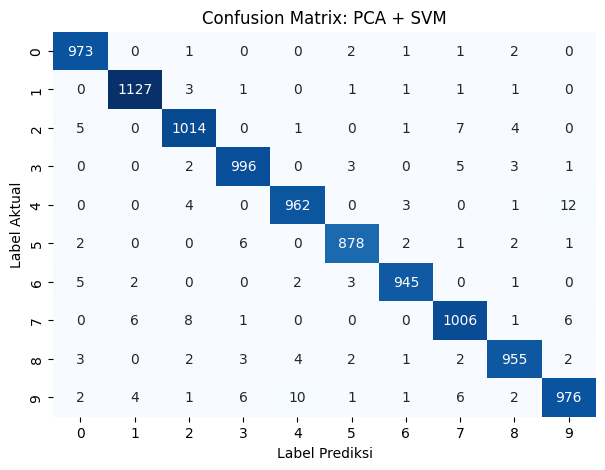

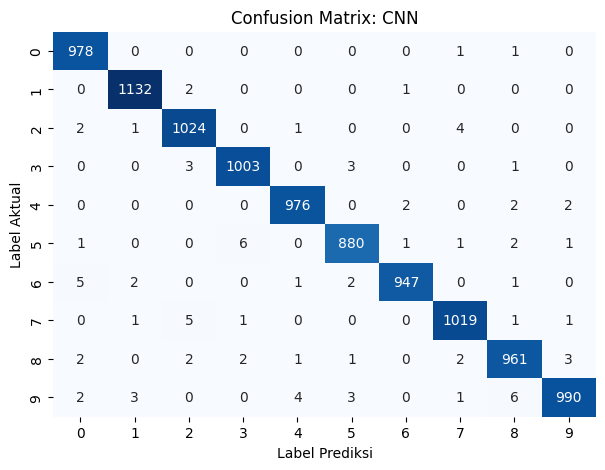

Menampilkan Contoh Gambar yang Gagal Diklasifikasi...


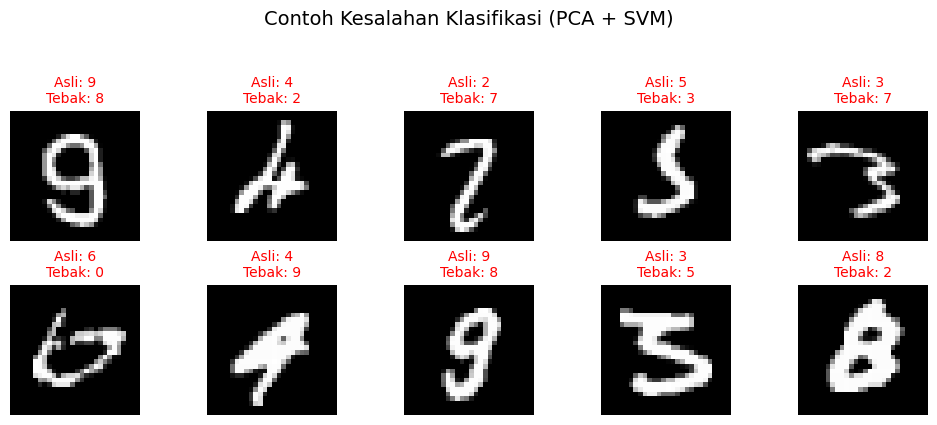

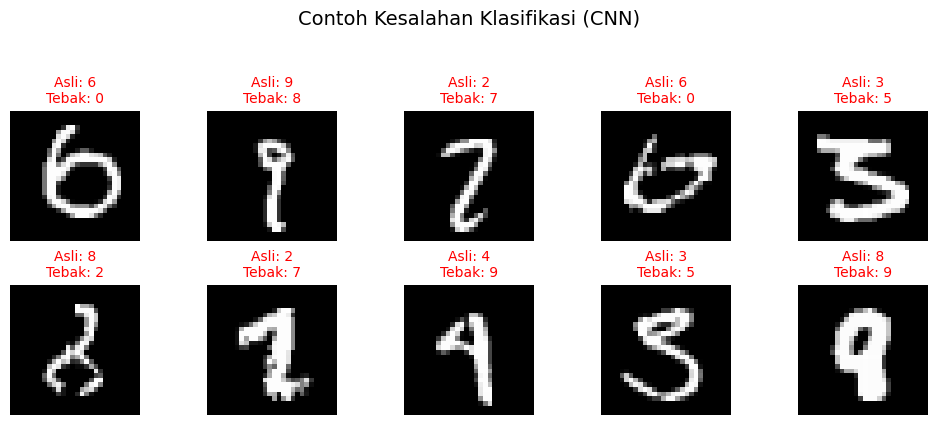

In [6]:
# TAHAP 6: ANALISIS KESALAHAN (ERROR ANALYSIS)

# 1. Menampilkan Confusion Matrix untuk Model Terbaik dari masing-masing pendekatan
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Label Prediksi')
    plt.ylabel('Label Aktual')
    plt.show()

print("Menampilkan Confusion Matrix...")
plot_cm(y_test, svm_pred, 'Confusion Matrix: PCA + SVM')
plot_cm(y_test, cnn_pred, 'Confusion Matrix: CNN')

# 2. Menampilkan Gambar yang Salah Klasifikasi (Misclassification)
def show_misclassified(y_true, y_pred, model_name):
    misclassified_idx = np.where(y_true != y_pred)[0]
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'Contoh Kesalahan Klasifikasi ({model_name})', fontsize=14, y=1.05)

    # Menampilkan 10 kesalahan pertama
    for i, idx in enumerate(misclassified_idx[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        plt.title(f'Asli: {y_true[idx]}\nTebak: {y_pred[idx]}', color='red', fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Menampilkan Contoh Gambar yang Gagal Diklasifikasi...")
show_misclassified(y_test, svm_pred, 'PCA + SVM')
show_misclassified(y_test, cnn_pred, 'CNN')